In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [50]:
df_all = pd.read_csv('/Users/gregorko/Desktop/Archive/data/symbol_info_3-25.csv')
print("Dataset shape:", df_all.shape)

summary_all = pd.DataFrame({"column": df_all.columns,
    "dtype": df_all.dtypes.astype(str).values,
    "missing_values": df_all.isna().sum().values,
})
display(df_all.head())
display(summary_all)

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


,column,dtype,missing_values
0,symbol,object,0
1,company_name,object,0
2,sector,object,2
3,industry,object,2
4,market_cap,int64,0
5,enterprise_value,uint64,0
6,current_price,float64,0
7,previous_close,float64,0
8,fifty_two_week_high,float64,0
9,fifty_two_week_low,float64,0


In [71]:
df = df_all.copy()
df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["sector"] == "Utilities")
][["company_name", "sector","symbol", "market_cap"]]

df["market_cap_billion"] = df["market_cap"] / 1000000000

summary = pd.DataFrame({"column": df.columns,
    "dtype": df.dtypes.astype(str).values,
})

display(df)

,company_name,sector,symbol,market_cap,market_cap_billion
73,"NextEra Energy, Inc.",Utilities,NEE,146357272576,146.357273
117,Southern Company (The),Utilities,SO,98679357440,98.679357
123,Duke Energy Corporation (Holdin,Utilities,DUK,93366894592,93.366895
124,GE Vernova Inc.,Utilities,GEV,92931710976,92.931711
172,Constellation Energy Corporatio,Utilities,CEG,69705211904,69.705212
209,American Electric Power Company,Utilities,AEP,56683405312,56.683405
249,"Dominion Energy, Inc.",Utilities,D,46845739008,46.845739
255,DBA Sempra,Utilities,SRE,45602037760,45.602038
260,Exelon Corporation,Utilities,EXC,45015011328,45.015011
261,Vistra Corp.,Utilities,VST,44866764800,44.866765


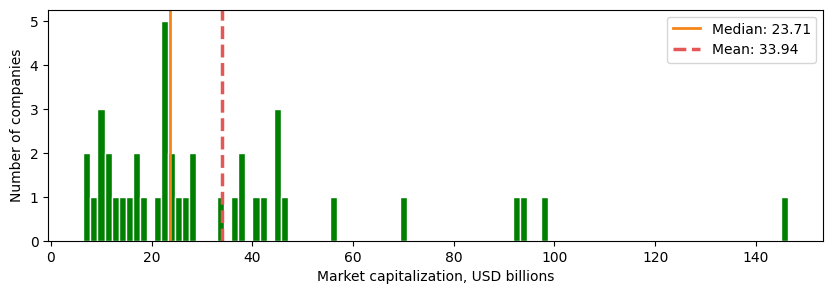

In [135]:
m_cap_b = df["market_cap_billion"].dropna()
figure, graph1 = plt.subplots(figsize=(10, 3))
graph1.hist(
m_cap_b, bins=100, color="green", edgecolor="white"
)

graph1.set_title("")
graph1.set_xlabel("Market capitalization, USD billions")
graph1.set_ylabel("Number of companies")

median_g1 = m_cap_b.median()
mean_g1 = m_cap_b.mean()

graph1.axvline(median_g1, color="#F58518", linestyle="-", linewidth=2, label=f"Median: {median_g1:.2f}")
graph1.axvline(mean_g1, color="#E45756", linestyle="--", linewidth=2.5, label=f"Mean: {mean_g1:.2f}")
graph1.legend()
plt.show()
